In [1]:
%load_ext autoreload

import os 
import sys
import time
import logging
import re
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from natsort import natsorted

import cv2
import numpy as np
from PIL import Image
import tifffile as tiff
import copy 
import random
from natsort import natsorted
import sys
from pathlib import Path

# Add GRIDGENE root to path
# You need to go up 2 levels
gridgene_root = Path.cwd().parent.parent  # analyses/quantification -> analyses -> GRIDGENE
sys.path.insert(0, str(gridgene_root))

print(f"Added to path: {gridgene_root}")
print(f"gridgene package location: {gridgene_root / 'gridgene'}")
from gridgene import get_arrays as ga
from gridgene import contours 
from gridgene import get_masks

Added to path: /home/martinha/PycharmProjects/phd/GRIDGENE
gridgene package location: /home/martinha/PycharmProjects/phd/GRIDGENE/gridgene


In [2]:
# define the logger :  can be None, and is set to INFO
# Custom logger setup
logger = logging.getLogger('contour_logger')
handler = logging.StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)
logger.setLevel(logging.INFO)

Reviewer 1 - Gap 1 - Lack of Quantitative Validation of Compartment Masks: While GRIDGENE-generated cancer and stroma masks are visually coherent across CosMx and Xenium platforms and align with reference images, the study does not provide quantitative metrics (e.g., IoU, Dice) comparing these masks to orthogonal ground-truth annotations from histopathology or protein staining. Without such validation, biological relevance is assumed rather than demonstrated, and the accuracy of compartment boundaries remains unverified. 



# Compare masks to protein markers

        CosMx IF
        CosMX masks

        Xenium IMC
        Xenium masks

## CosMx 
Map CosMx cohort with the IF data

CosMx paths

In [3]:
cosmx_path_s0 =  '/home/martinha/PycharmProjects/phd/spatial_transcriptomics/cosmx_data/S0/S0/20230628_151317_S4/AnalysisResults/iz38iruwno'

folder_names_s0 = [folder_name for folder_name in os.listdir(cosmx_path_s0) if
                os.path.isdir(os.path.join(cosmx_path_s0, folder_name))]

target_files_s0 = [
    os.path.join(cosmx_path_s0, folder, file)
    for folder in os.listdir(cosmx_path_s0)
    if os.path.isdir(os.path.join(cosmx_path_s0, folder))
    for file in os.listdir(os.path.join(cosmx_path_s0, folder))
    if '__target_call_coord.csv' in file
]

files_names = natsorted(target_files_s0)
files_cosmx = copy.deepcopy(files_names)

In [4]:
# param cancer
target_tum =  ['EPCAM',  'KRT19', 'KRT8', 'KRT18','KRT17','CEACAM6','SPINK1', 'CD24', 'S100A6','RPL37','S100P',]  
density_th_tum = 40    
min_area_th_tum =  1000 
kernel_size_tum = 80

# param empty
density_th_empty = 140
min_area_th_empty = 2000 
kernel_size_empty = 80

In [7]:
file_csv = files_names[0]   # 5
df_total = pd.read_csv(file_csv)
df_total['X'] = (round(df_total['x'])).astype(int)
df_total['Y'] = (round(df_total['y'])).astype(int)

print('max x', max(df_total['x']))
print('max y', max(df_total['y']))
print('rounded max x', max(df_total['X']))
print('rounded max y', max(df_total['Y']))

print('df shape', df_total.shape)
print('df columns', df_total.columns)

df_total['target'].value_counts()

# remove Controls
df_total = df_total[~df_total['target'].str.contains('System|egative')]
n_genes = len(df_total['target'].unique())
height = max(df_total['X'] + 1)
width = max(df_total['Y'] + 1)

print(f'n genes: {n_genes}')
print(f'shape: {height}, {width}')
print(f'n hits {len(df_total)}')

# this makes the sparse df to an array with the spatial information 
target_dict_total = {target: index for index, target in enumerate(df_total['target'].unique())}
array_total = ga.transform_df_to_array(df = df_total, target_dict=target_dict_total, array_shape = (height, width,len(target_dict_total))).astype(np.int8)

# creating subsets 
df_subset_tum, array_subset_tum, target_indices_subset_tum = ga.get_subset_arrays(df_total, array_total,target_dict_total,
                                                                     target_list=target_tum, target_col = 'target')

max x 4245.27
max y 4245.32
rounded max x 4245
rounded max y 4245
df shape (1843019, 22)
df columns Index(['Unnamed: 0', 'Spot1_count', 'Spot2_count', 'Spot3_count',
       'Spot4_count', 'codeclass', 'fov', 'multicolor_spots_per_feature',
       'possible_BC_count', 'random_call_probability', 'seed_x', 'seed_y',
       'spots_per_feature', 'target', 'target_call_observations',
       'target_count_per_feature', 'target_idx', 'x', 'y', 'z', 'X', 'Y'],
      dtype='object')
n genes: 999
shape: 4246, 4246
n hits 1819904


2025-12-06 00:12:08,298 - gridgene.contours.tum - INFO - Initialized GetContour
2025-12-06 00:12:08,812 - gridgene.contours.tum - INFO - get_conv_sum took 0.5127 seconds
2025-12-06 00:12:09,188 - gridgene.contours.tum - INFO - Number of contours after filtering no counts: 38
2025-12-06 00:12:09,189 - gridgene.contours.tum - INFO - contours_from_sum took 0.3760 seconds
2025-12-06 00:12:09,189 - gridgene.contours.empty - INFO - Initialized GetContour
2025-12-06 00:12:16,490 - gridgene.contours.empty - INFO - get_conv_sum took 7.3002 seconds
2025-12-06 00:12:23,532 - gridgene.contours.empty - INFO - Number of contours after filtering no counts: 35
2025-12-06 00:12:23,533 - gridgene.contours.empty - INFO - contours_from_sum took 7.0425 seconds


====
N contours for tissue area 35
N contours for cancer 38


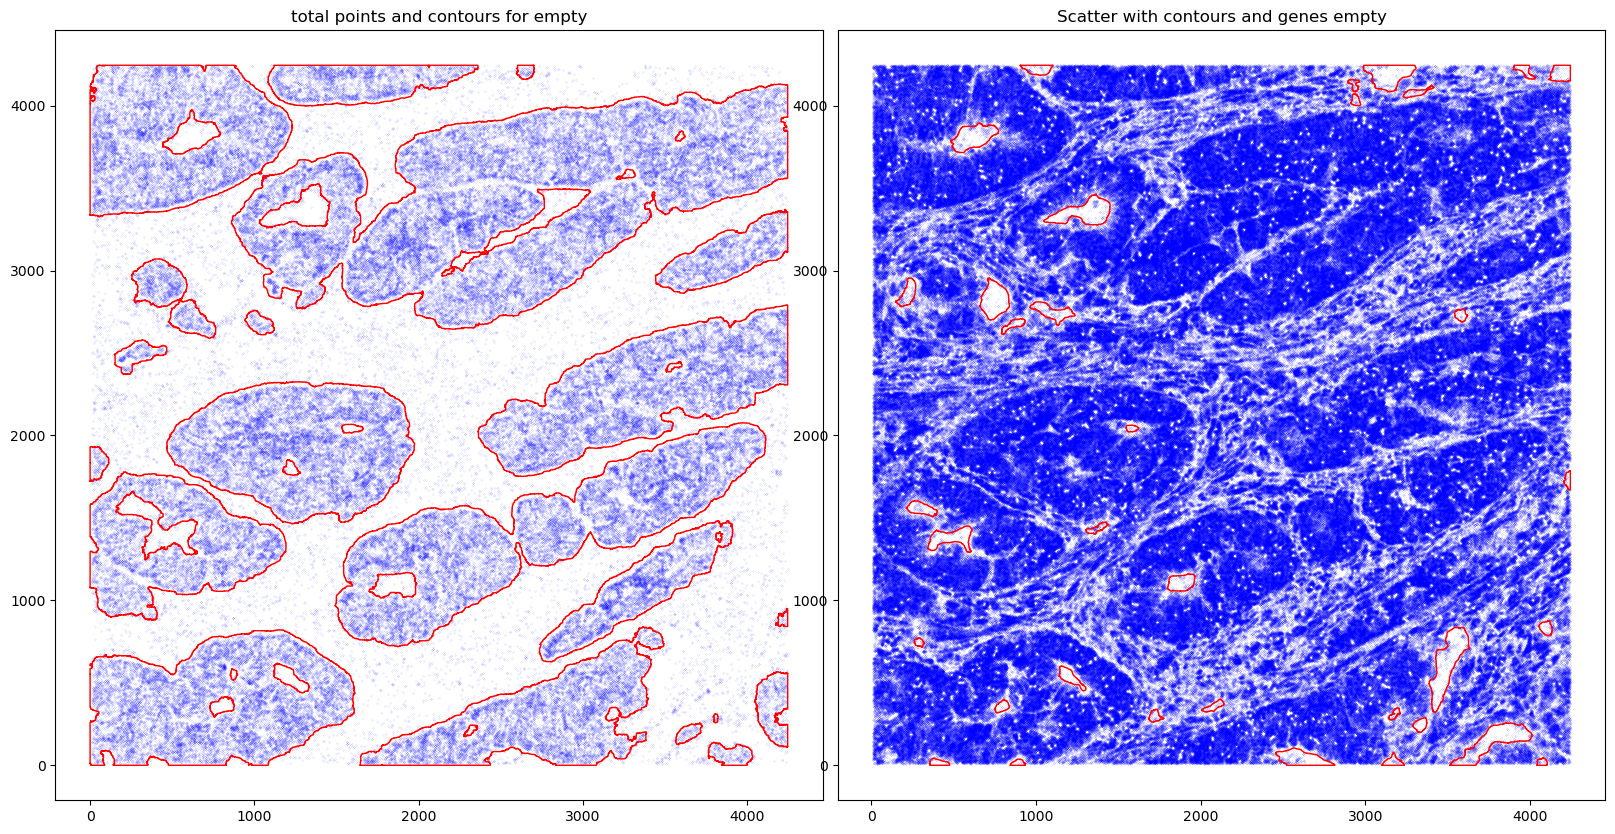

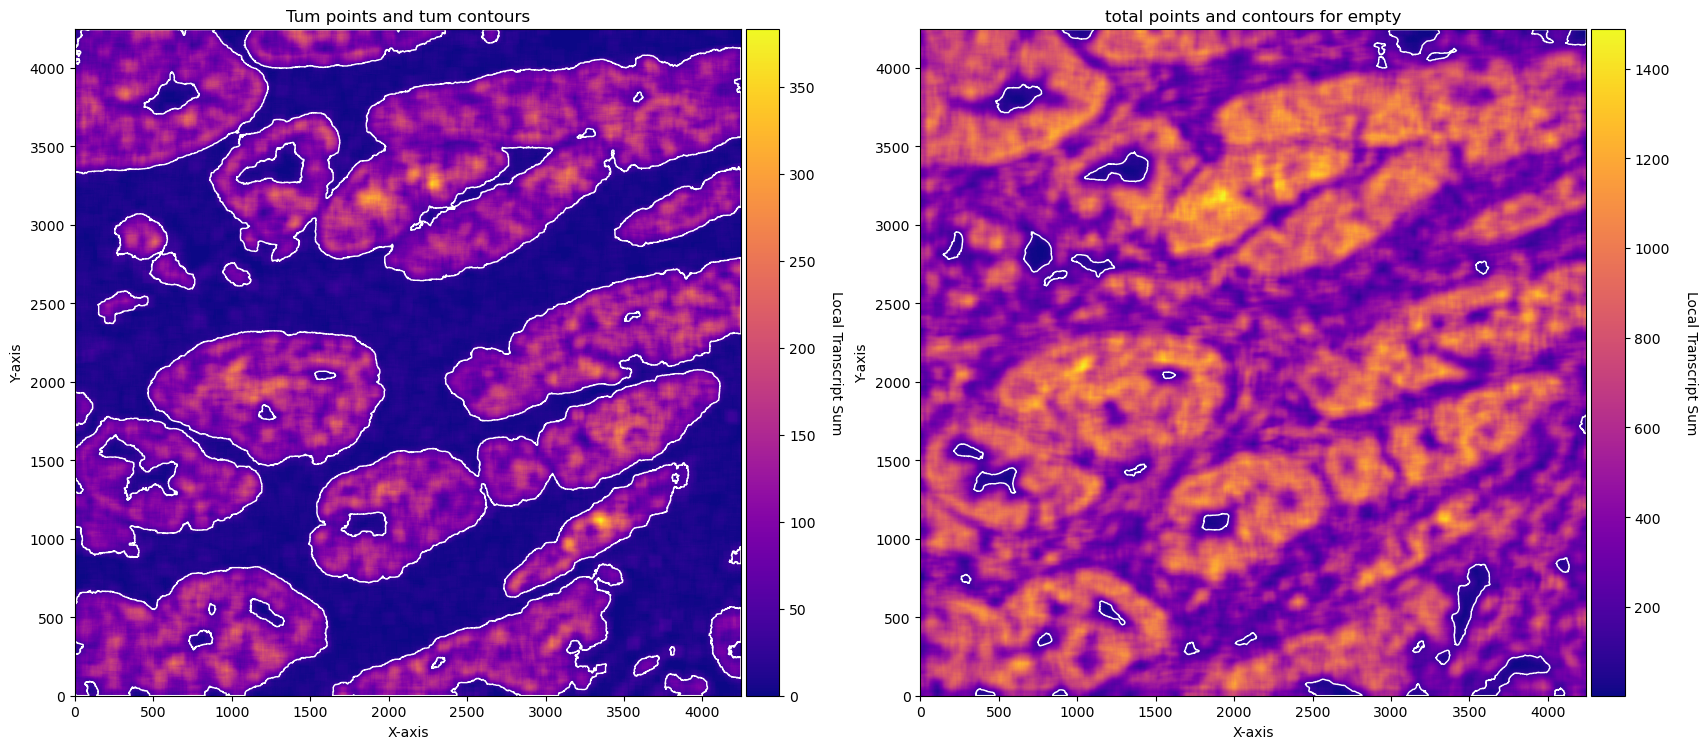

In [8]:
# obtain contours 
CTum = contours.ConvolutionContours(array_subset_tum, contour_name='tum')
CTum.get_conv_sum(kernel_size=kernel_size_tum, kernel_shape='square')
CTum.contours_from_sum(density_threshold = density_th_tum,
                       min_area_threshold = min_area_th_tum , directionality = 'higher')

CEmpty = contours.ConvolutionContours(array_total, contour_name='empty')
CEmpty.get_conv_sum(kernel_size=kernel_size_empty, kernel_shape='square')
CEmpty.contours_from_sum(density_threshold = density_th_empty,
                       min_area_threshold = min_area_th_empty, directionality = 'lower') # attention that directionality is lower here 


print('====')
print('N contours for tissue area', len(CEmpty.contours))
print('N contours for cancer', len(CTum.contours))

# PLOTs -- instead of plotting just with the function for example: CTum.plot_contours_scatter, we will make a composite image 

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
CTum.plot_contours_scatter(path=None, show=False, s=0.05, alpha=0.5, linewidth=1,
                           c_points= 'blue',c_contours= 'red', ax=axs[0])
axs[0].set_title('Tum points and tum contours')  


CEmpty.plot_contours_scatter(path=None, show=False, s=0.05, alpha=0.5, linewidth=1,
                           c_points= 'blue',c_contours= 'red', ax=axs[1])
axs[0].set_title('total points and contours for empty')  
plt.subplots_adjust(wspace=0.02)  # Adjust to your preference

plt.show()
   

fig, axs = plt.subplots(1, 2, figsize=(20, 10))

CTum.plot_conv_sum(cmap='plasma', c_countour='white', ax=axs[0])
axs[0].set_title('Tum points and tum contours')

CEmpty.plot_conv_sum(cmap='plasma', c_countour='white', ax=axs[1])
axs[1].set_title('total points and contours for empty')

plt.show()

2025-12-06 00:12:34,161 - gridgene.get_masks.GetMasks - INFO - Initialized GetMasks
2025-12-06 00:12:34,199 - gridgene.get_masks.GetMasks - INFO - Subtracted masks from base mask.


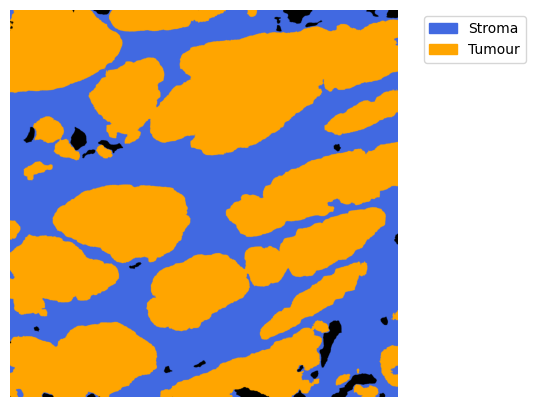

In [9]:
#### obtain masks
GM = get_masks.GetMasks(image_shape = (height, width))

mask_empty = GM.create_mask(CEmpty.contours)
mask_tum = GM.create_mask(CTum.contours)
mask_tum = GM.fill_holes(mask_tum)
mask_stroma = GM.subtract_masks(np.ones((height, width), dtype=np.uint8), mask_tum, mask_empty)          
mask_stroma = GM.filter_binary_mask_by_area(mask_stroma, min_area=700)

GM.plot_masks(masks=[mask_stroma, mask_tum], mask_names=['Stroma', 'Tumour'],
              background_color=(1, 1, 1), mask_colors={'Stroma': (65, 105, 225), 'Tumour': (255, 165, 0)},
              path=None, show=True, ax=None, figsize=(5, 6))

Overlay contours with ground truth

Just as an example, We will overlay this mask with the correspondent immunofluorescent image. In the IF image, nucleus are coloured with DAPI blue, cancer with red and the remaining membranes with green. For the lines, yellow represent the stroma contours and white cancer contours.

It's possible to see a very good overlap between regions.

Some discrepancies may be due to problems in the IF imaging and the non complete alignment as the IF and the CosMx are made on consecutive slides.

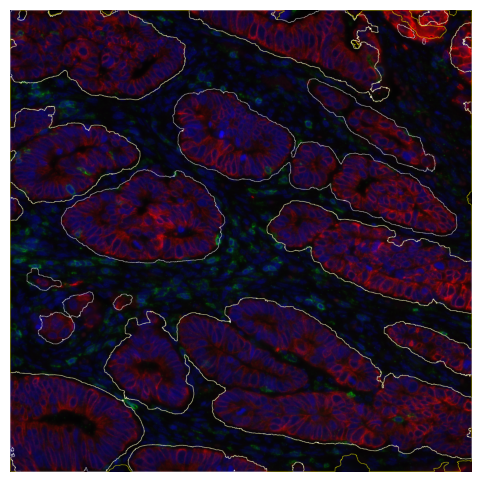

In [11]:
image = tiff.imread('/home/martinha/PycharmProjects/phd/spatial_transcriptomics/GRIDGEN/case_studies/composites/20230628_151317_S4_C902_P99_N99_F001_composite.tiff')

# Calculate the padding needed on each side
pad_y = (image.shape[1] - mask_stroma.shape[1]) // 2
pad_x = (image.shape[0] - mask_stroma.shape[0]) // 2

# Pad the mask with 5 pixels on each side to match the image size
# Here, we assume a binary mask, so we pad with 0s
mask1 = np.pad(mask_stroma, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
mask2 = np.pad(mask_tum, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)

# mask1 = np.flip(mask1, axis = 0) 
mask1 = np.transpose(mask1)
mask2 = np.transpose(mask2)
image = (image * 255).astype(np.uint8)

# Create a copy of the image to overlay borders
image_with_contours = image.copy()

# Find contours for each mask
contours1, _ = cv2.findContours(mask1.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours2, _ = cv2.findContours(mask2.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Define colors for each mask's contours (Yellow for mask1, Cyan for mask2)
contour_color1 = (255, 255, 0)  # Yellow
contour_color2 = (255, 255, 255)  # Cyan

# Draw the contours on the image
cv2.drawContours(image_with_contours, contours1, -1, contour_color1, thickness=2)
cv2.drawContours(image_with_contours, contours2, -1, contour_color2, thickness=2)

# Plot the image with contours
plt.figure(figsize=(6, 6))  # Increase the figure size to make it larger
plt.imshow(image_with_contours)
plt.axis('off')  # Hide axes for cleaner visualization
plt.show()

In [ ]:
def do_cosmx_pipeline(file_csv):
    df_total = pd.read_csv(file_csv)
    df_total['X'] = (round(df_total['x'])).astype(int)
    df_total['Y'] = (round(df_total['y'])).astype(int)
    n_genes = len(df_total['target'].unique())
    height = max(df_total['X'] + 1)
    width = max(df_total['Y'] + 1)
    target_dict_total = {target: index for index, target in enumerate(df_total['target'].unique())}
    array_total = ga.transform_df_to_array(df = df_total, target_dict=target_dict_total, array_shape = (height, width,len(target_dict_total))).astype(np.int8)
    df_subset_tum, array_subset_tum, target_indices_subset_tum = ga.get_subset_arrays(df_total, array_total,target_dict_total,
                                                                         target_list=target_tum, target_col = 'target')
    
    # obtain contours 
    CTum = contours.ConvolutionContours(array_subset_tum, contour_name='tum')
    CTum.get_conv_sum(kernel_size=kernel_size_tum, kernel_shape='square')
    CTum.contours_from_sum(density_threshold = density_th_tum,
                           min_area_threshold = min_area_th_tum , directionality = 'higher')
    
    CEmpty = contours.ConvolutionContours(array_total, contour_name='empty')
    CEmpty.get_conv_sum(kernel_size=kernel_size_empty, kernel_shape='square')
    CEmpty.contours_from_sum(density_threshold = density_th_empty,
                           min_area_threshold = min_area_th_empty, directionality = 'lower') # attention that directionality is lower here 

        

    #### obtain masks
    GM = get_masks.GetMasks(image_shape = (height, width))
    
    mask_empty = GM.create_mask(CEmpty.contours)
    mask_tum = GM.create_mask(CTum.contours)
    mask_tum = GM.fill_holes(mask_tum)
    mask_stroma = GM.subtract_masks(np.ones((height, width), dtype=np.uint8), mask_tum, mask_empty)          
    mask_stroma = GM.filter_binary_mask_by_area(mask_stroma, min_area=700)
        
        
    fig, axs = plt.subplots(1, 3, figsize=(26, 8))
    CTum.plot_contours_scatter(path=None, show=False, s=0.05, alpha=0.5, linewidth=1,
                               c_points= 'blue',c_contours= 'red', ax=axs[0])
    axs[0].set_title('Tum points and tum contours')  
    
    
    CEmpty.plot_contours_scatter(path=None, show=False, s=0.05, alpha=0.5, linewidth=1,
                               c_points= 'blue',c_contours= 'red', ax=axs[1])
    axs[1].set_title('total points and contours for empty')  
    plt.subplots_adjust(wspace=0.02)  # Adjust to your preference
    
    GM.plot_masks(masks=[mask_stroma, mask_tum], mask_names=['Stroma', 'Tumour'],
                  background_color=(1, 1, 1), mask_colors={'Stroma': (65, 105, 225), 'Tumour': (255, 165, 0)},
                  path=None, show=False, ax=axs[2])
    axs[2].set_title('Masks')  

    plt.show()

In [ ]:
%%time

files_names = natsorted(target_files_s0)


for file_csv in tqdm(random.sample(files_names, 5)):
    do_cosmx_pipeline(file_csv)

## Xenium 

Map the 3 cores we have pairs IMC - Xenium

Read the IMC files

Perguntar se os IMC files estão clean! ou se vou ter de fazer ue os parametros! 
tgfbeta 40 0.2 

In [ ]:
Supplementary Table 1 - Thresholds and percentile values for the 39 IMC markers
Marker	Percentile	Threshold	Marker	Percentile	Threshold
B catenin	60	0.2	CD8a	60	0.25
CD103	30	0.1	cleavedcaspase	40	0.3
CD11b	50	0.25	D2-40	50	0.25
CD11c	40	0	FOXP3	50	0.1
CD14	40	0.1	Granzyme B	40	0.2
CD15	40	0.25	HLA-DR	50	0.1
CD163	40	0.3	ICOS	50	0.1
CD20	50	0.1	IDO	30	0.3
CD204	50	0.1	Keratin	50	0.5
CD3	50	0.1	Ki-67	50	0.2
CD31	50	0,2	P16ink4a	50	0.2
CD38	40	0.2	PD-1	40	0.2
CD39	40	0.2	PD-L1	50	0.3
CD4	50	0.2	Tbet	60	0.1
CD45 	50	0.2	TCRgd	40	0.1
CD45RO	50	0.2	TGFbeta	40	0.2
CD56	50	0.2	Vimentin	40	0.1
CD57	60	0.2	VISTA	50	0.2
CD68	40	0.2	CD7	50	0.2


In [ ]:
fetch the data for these rois
cretae masks

In [ ]:
METRICS

Compare masks to cell segmentation :

        CosMx cell segmentation
        Xenium cell segmentation
        
        CosMx masks
        Xenium masks 
        